In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option("display.max_columns",None)
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("german_credit_data.csv")

## Dataset Link: https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk

In [4]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [5]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [6]:
df.shape

(1000, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [8]:
df.describe(include='all').transpose().round(2).T

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.0,1000.0,1000,1000.0,1000,817,606,1000.0,1000.0,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.5,35.546,NaN,1.904,NaN,NaN,NaN,3271.258,20.903,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.0,19.0,NaN,0.0,NaN,NaN,NaN,250.0,4.0,NaN,NaN
25%,249.75,27.0,NaN,2.0,NaN,NaN,NaN,1365.5,12.0,NaN,NaN
50%,499.5,33.0,NaN,2.0,NaN,NaN,NaN,2319.5,18.0,NaN,NaN
75%,749.25,42.0,NaN,2.0,NaN,NaN,NaN,3972.25,24.0,NaN,NaN


In [9]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.dropna().reset_index(drop=True)

In [12]:
df.isnull().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [13]:
df.shape

(522, 11)

In [14]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [15]:
df.drop(columns = "Unnamed: 0", inplace = True)

In [16]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

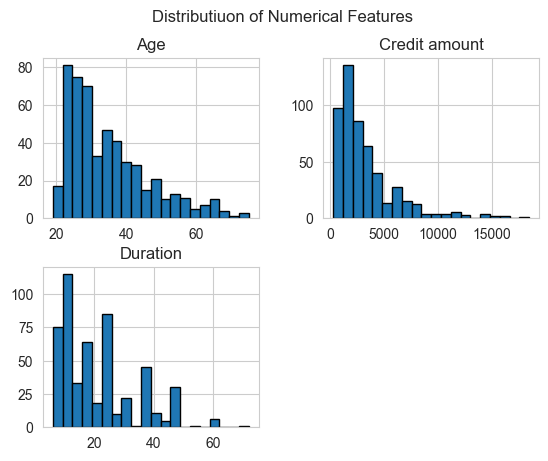

In [17]:
df[["Age","Credit amount","Duration"]].hist(bins=20, edgecolor="black")
plt.suptitle("Distributiuon of Numerical Features")
plt.show()

In [18]:
df[["Age","Credit amount","Duration"]].skew().round(2)

Age              1.12
Credit amount    2.06
Duration         1.06
dtype: float64

In [19]:
df[["Age","Credit amount","Duration"]].kurt().round(2)

Age              0.68
Credit amount    4.95
Duration         0.66
dtype: float64

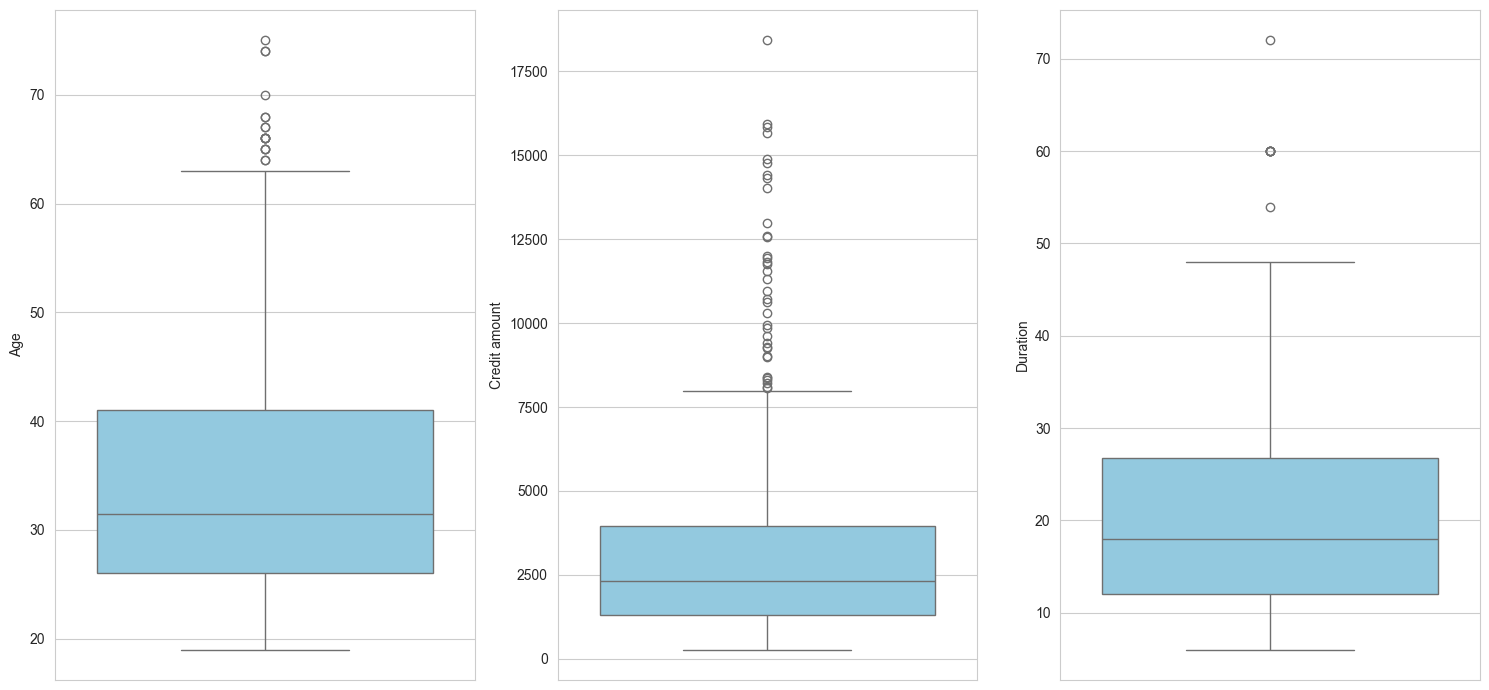

In [20]:
plt.figure(figsize=(15,7))
for i, col in enumerate (["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col],color='skyblue')

plt.tight_layout()
plt.show()

In [21]:
categorical_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

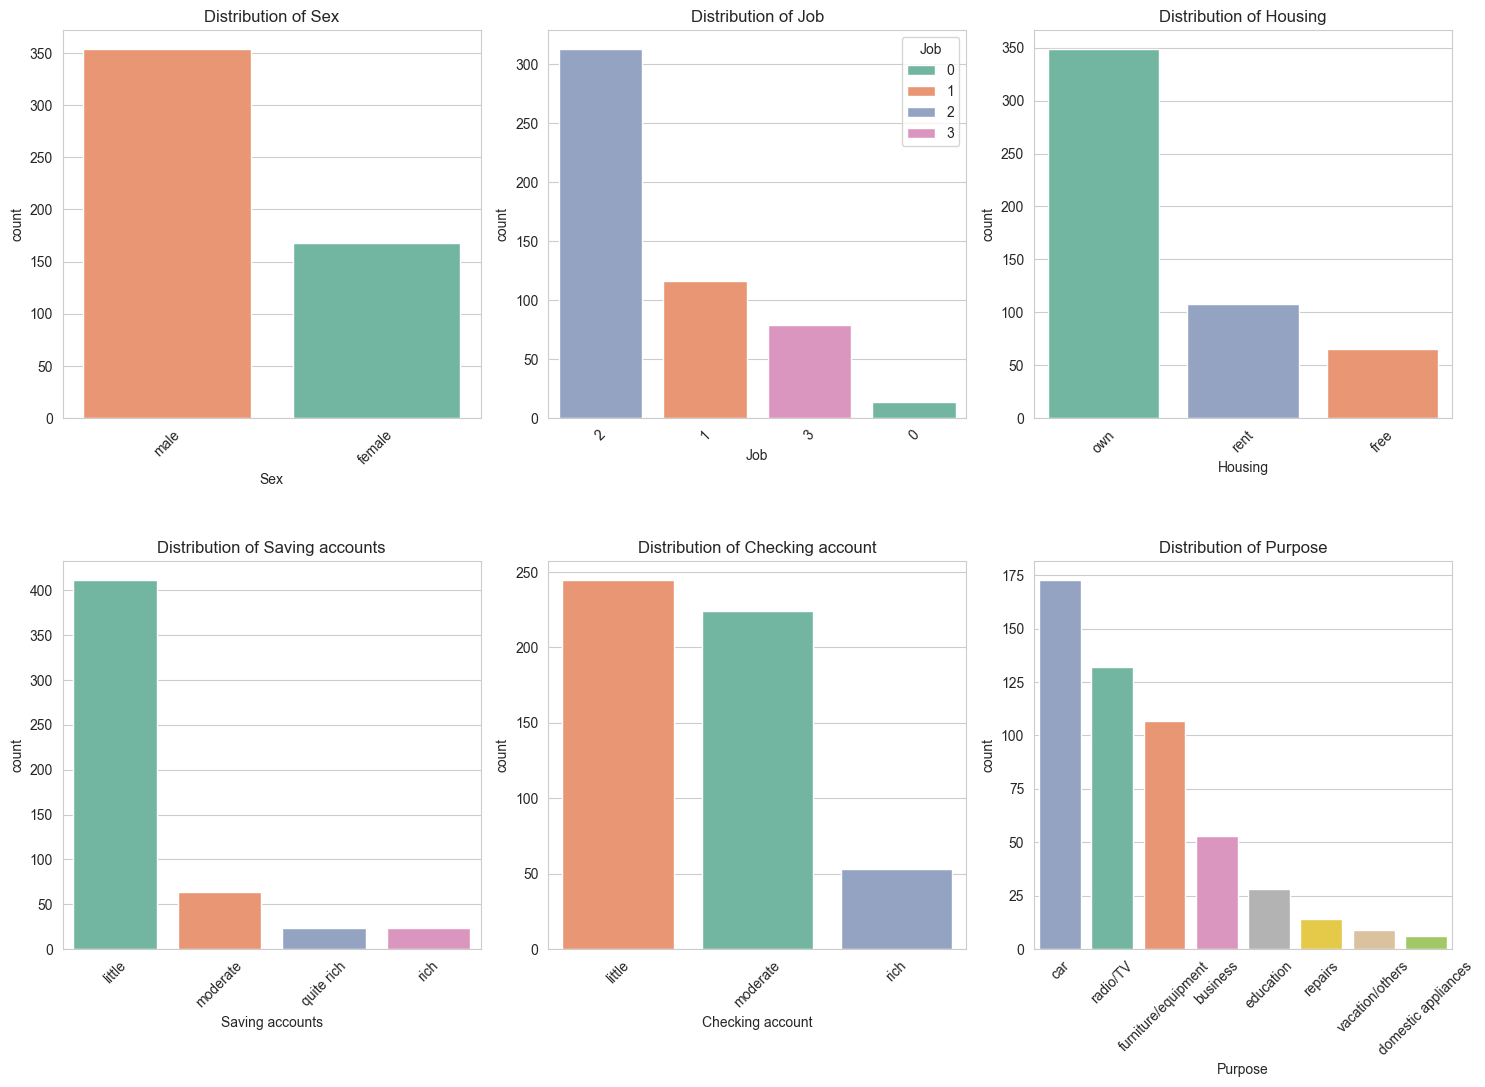

In [22]:
plt.figure(figsize=(15,15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, 
                  x=col,
                  hue=col,
                  palette='Set2',
                  order = df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [24]:
corr = df[['Age','Job','Credit amount', 'Duration']].corr().round(2)
corr

,Age,Job,Credit amount,Duration
Age,1.00,0.04,0.08,0.00
Job,0.04,1.00,0.33,0.20
Credit amount,0.08,0.33,1.00,0.61
Duration,0.00,0.20,0.61,1.00


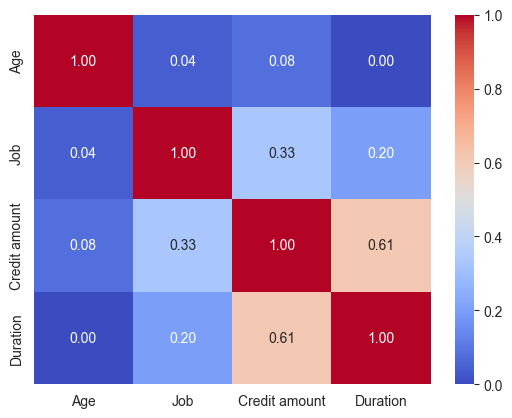

In [25]:
sns.heatmap(corr, annot=True, cmap = 'coolwarm',fmt='.2f')
plt.show()

In [26]:
df.groupby("Job")["Credit amount"].mean().round(2)

Job
0    1767.86
1    2250.72
2    3129.13
3    5648.78
Name: Credit amount, dtype: float64

In [27]:
df.groupby("Sex")["Credit amount"].mean().round(2)

Sex
female    2937.20
male      3440.83
Name: Credit amount, dtype: float64

In [28]:
pd.pivot_table(df, values='Credit amount', index='Housing', columns='Purpose').round(2)

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.00,5180.31,NaN,5314.25,4419.44,2097.00,1190.0,7842.67
own,3725.97,3120.49,1333.5,2625.08,3031.10,2307.61,2993.5,10321.83
rent,6180.83,3398.29,NaN,2627.86,2890.29,2138.00,2384.0,NaN


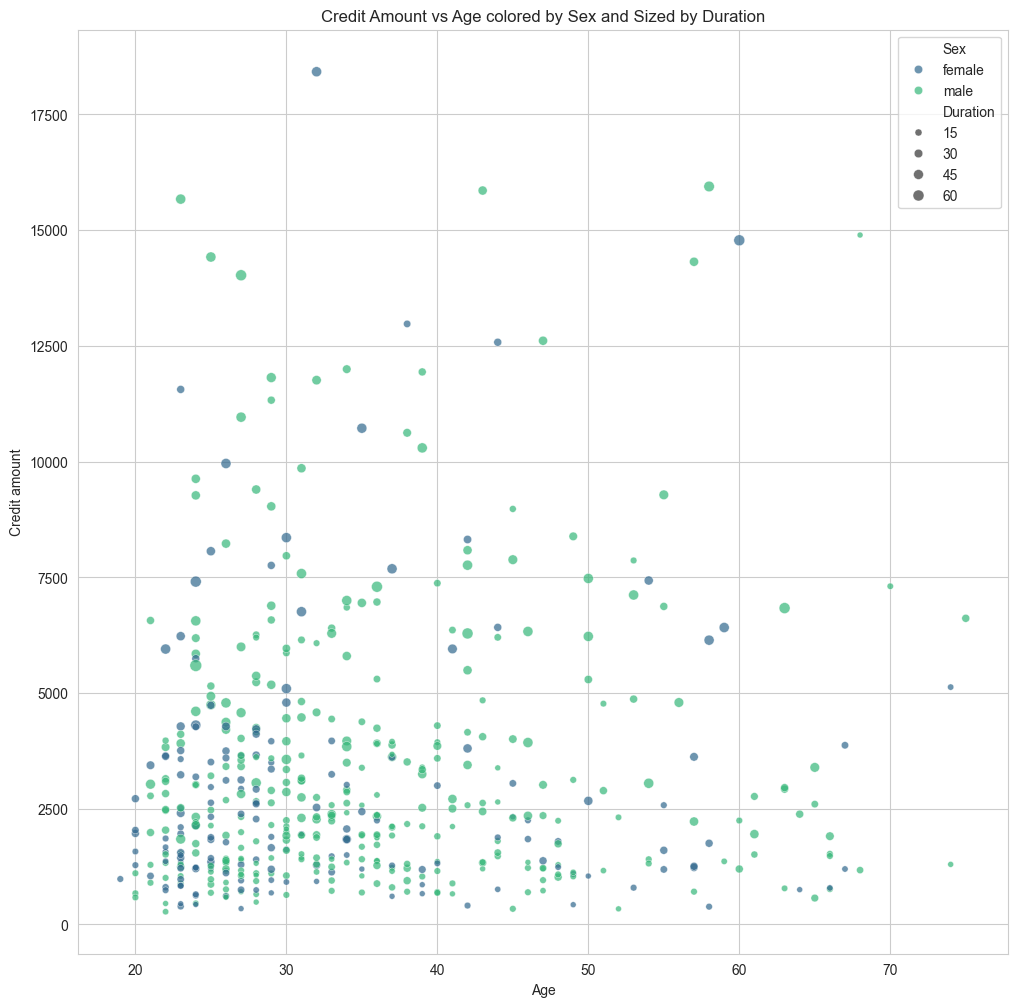

In [29]:
plt.figure(figsize=(12,12))
sns.scatterplot(data=df, 
                x='Age',
                y='Credit amount', 
                hue='Sex',
                size='Duration',
                alpha=0.7,
                palette='viridis')
plt.title("Credit Amount vs Age colored by Sex and Sized by Duration")
plt.show()

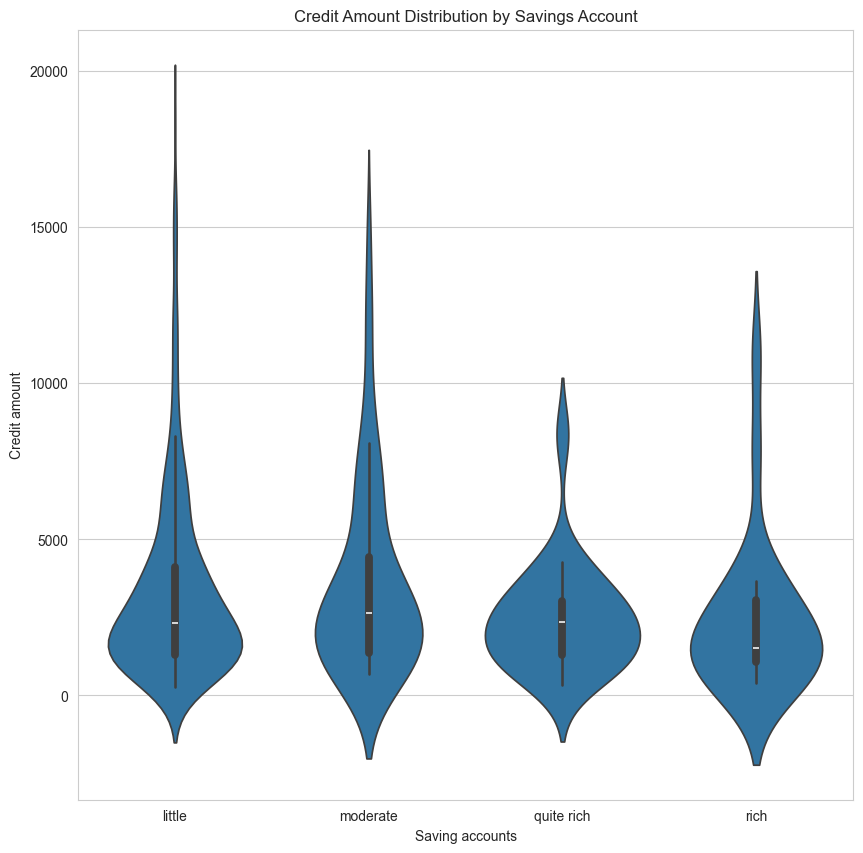

In [30]:
plt.figure(figsize=(10,10))
sns.violinplot(data=df, x="Saving accounts",y='Credit amount')
plt.title("Credit Amount Distribution by Savings Account")
plt.show()

In [31]:
df['Risk'].value_counts(normalize=True)*100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

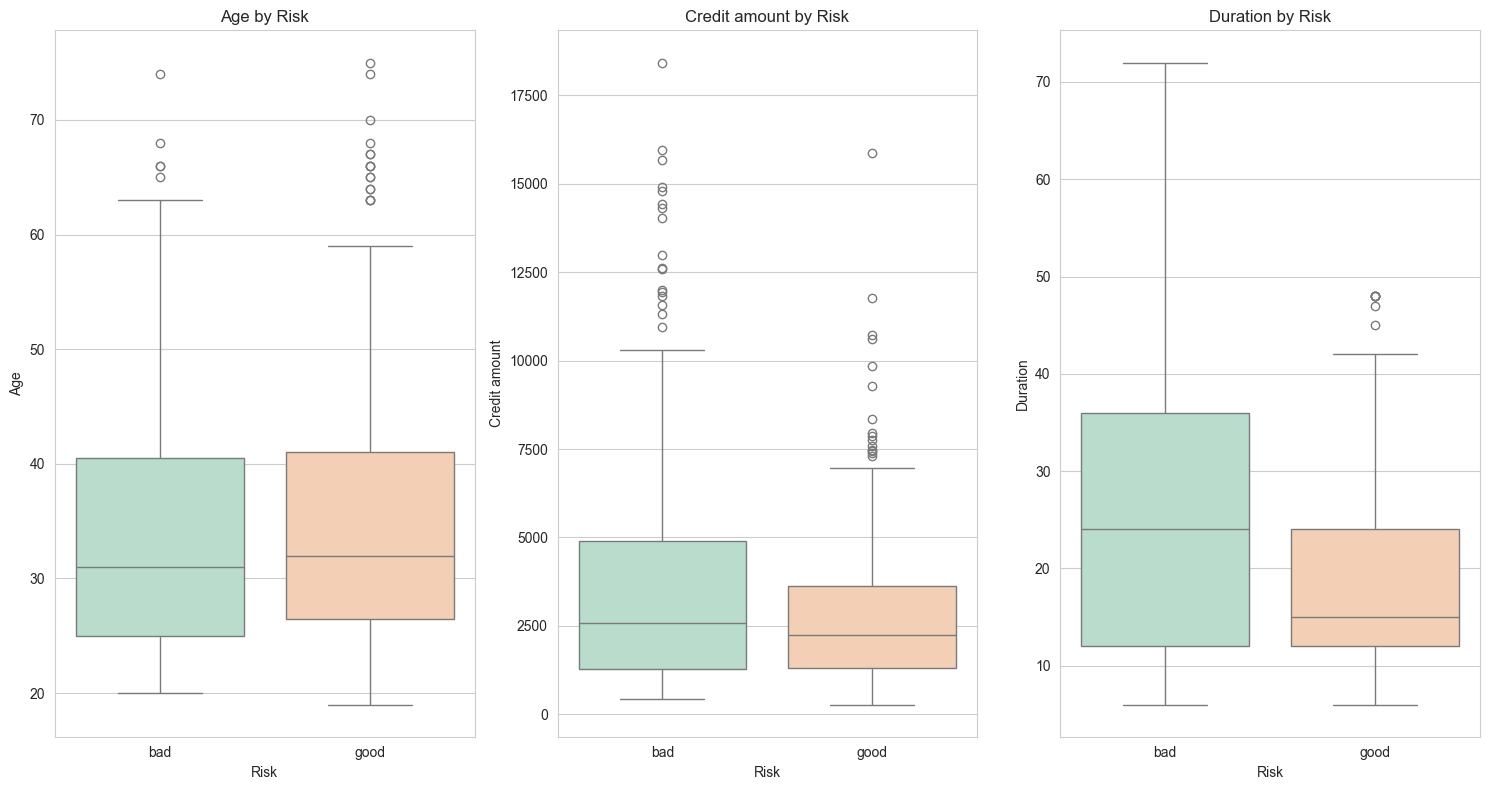

In [32]:
plt.figure(figsize=(15,8))
for i, col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x = 'Risk', y=col, palette='Pastel2')
    plt.title(f'{col} by Risk')

plt.tight_layout()
plt.show()

In [34]:
df.groupby('Risk')[["Age","Credit amount","Duration"]].mean().round(2)

,Age,Credit amount,Duration
Risk,,,
bad,34.15,3881.09,25.45
good,35.48,2800.59,18.08


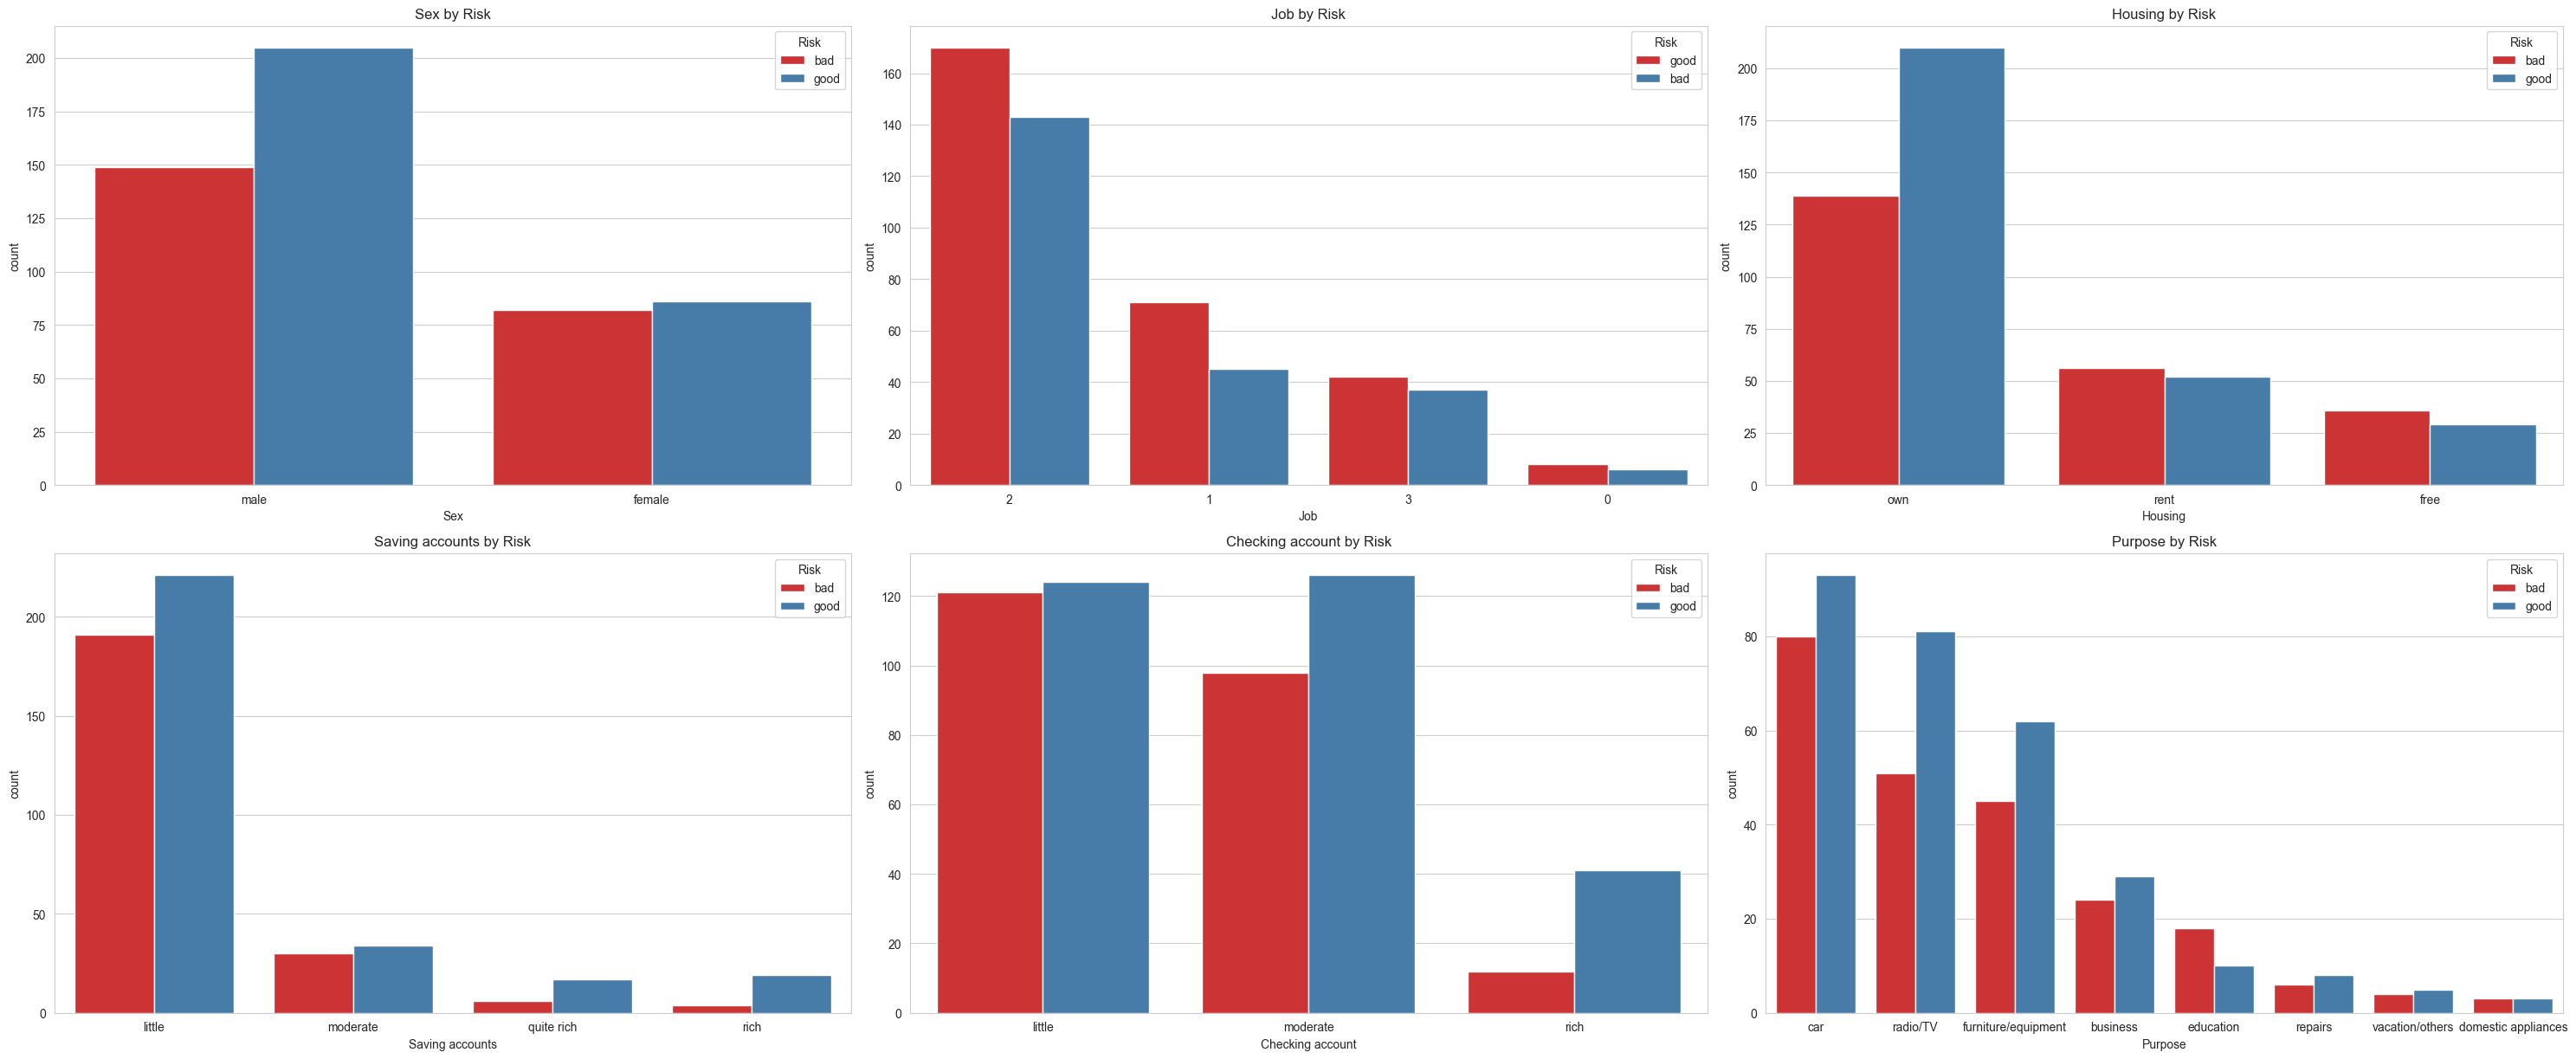

In [46]:
plt.figure(figsize=(30,18))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col , hue='Risk',palette="Set1",order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [47]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [48]:
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account','Credit amount', 'Duration']
target = 'Risk'

In [49]:
df_model = df[features + [target]].copy()

In [50]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [53]:
cat_col = df_model.select_dtypes(include = "object").columns.drop('Risk')

In [54]:
le_dict = {}

In [55]:
cat_col

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [56]:
for col in cat_col:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le,f"{col}_encoder.pkl")

In [57]:
le_target = LabelEncoder()

In [58]:
target

'Risk'

In [59]:
df_model[target] = le_target.fit_transform(df_model[target])

In [61]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [62]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [64]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [68]:
x = df_model.drop(target, axis=1)
y = df_model[target]

In [70]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify=y, random_state=42)

In [73]:
x_train.shape

(417, 8)

In [74]:
y_test.shape

(105,)